In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Activation,
    Dropout, GlobalAveragePooling1D, Dense
)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
columns = ['user', 'activity', 'timestamp', 'accel_x', 'accel_y', 'accel_z']

df = pd.read_csv(
    '/content/WISDM_ar_v1.1_raw.txt',
    header=None,
    names=columns,
    sep=',',
    engine='python',
    on_bad_lines='skip'
)

print(df.head())
print(df.shape)


   user activity       timestamp   accel_x    accel_y       accel_z
0    33  Jogging  49105962326000 -0.694638  12.680544   0.50395286;
1    33  Jogging  49106062271000  5.012288  11.264028   0.95342433;
2    33  Jogging  49106112167000  4.903325  10.882658  -0.08172209;
3    33  Jogging  49106222305000 -0.612916  18.496431    3.0237172;
4    33  Jogging  49106332290000 -1.184970  12.108489     7.205164;
(1086466, 6)


In [ ]:
sensor_cols = ['accel_x', 'accel_y', 'accel_z']

df[sensor_cols] = (
    df[sensor_cols]
    .astype(str)
    .replace(';', '', regex=True)
    .apply(pd.to_numeric, errors='coerce')
)

df.dropna(inplace=True)
print(df[sensor_cols].dtypes)

accel_x    float64
accel_y    float64
accel_z    float64
dtype: object


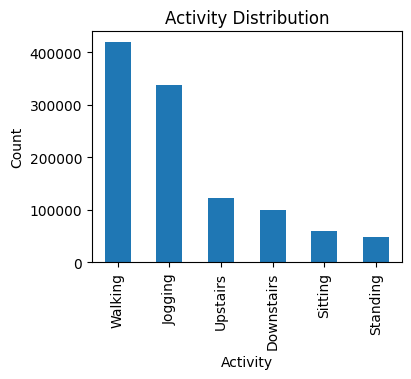

In [ ]:
plt.figure(figsize=(4,3))
df['activity'].value_counts().plot(kind='bar')
plt.title("Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.show()

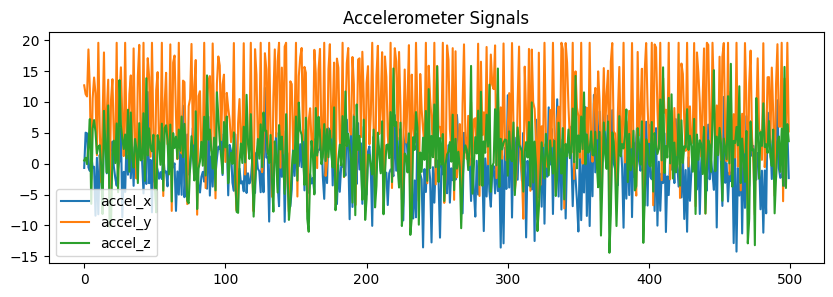

In [ ]:
plt.figure(figsize=(10,3))
plt.plot(df['accel_x'].values[:500], label='accel_x')
plt.plot(df['accel_y'].values[:500], label='accel_y')
plt.plot(df['accel_z'].values[:500], label='accel_z')
plt.legend()
plt.title("Accelerometer Signals")
plt.show()

In [ ]:
le = LabelEncoder()
df['activity_label'] = le.fit_transform(df['activity'])

print(df[['activity', 'activity_label']].drop_duplicates())

          activity  activity_label
0          Jogging               1
597        Walking               5
1161      Upstairs               4
1769    Downstairs               0
221331     Sitting               2
223430    Standing               3


In [ ]:
WINDOW_SIZE = 128
STEP_SIZE   = 64

X = []
y = []

for user in df['user'].unique():
    user_df = df[df['user'] == user]

    data   = user_df[sensor_cols].values
    labels = user_df['activity_label'].values

    for i in range(0, len(data) - WINDOW_SIZE, STEP_SIZE):
        X.append(data[i:i+WINDOW_SIZE])
        y.append(np.bincount(labels[i:i+WINDOW_SIZE]).argmax())

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  # (samples, 128, 3)
print("y shape:", y.shape)

X shape: (16922, 128, 3)
y shape: (16922,)


In [ ]:
scaler = StandardScaler()

X_flat = X.reshape(-1, X.shape[-1])
X_norm = scaler.fit_transform(X_flat)
X = X_norm.reshape(X.shape)

Epoch 1/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7348 - loss: 0.8172 - val_accuracy: 0.7710 - val_loss: 0.6721
Epoch 2/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8111 - loss: 0.5627 - val_accuracy: 0.8346 - val_loss: 0.5017
Epoch 3/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8317 - loss: 0.4850 - val_accuracy: 0.8663 - val_loss: 0.4339
Epoch 4/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8544 - loss: 0.4248 - val_accuracy: 0.8737 - val_loss: 0.3724
Epoch 5/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8659 - loss: 0.3883 - val_accuracy: 0.9073 - val_loss: 0.3496
Epoch 6/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8824 - loss: 0.3511 - val_accuracy: 0.9165 - val_loss: 0.3026
Epoch 7/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8906 - loss: 0.3262 - val_accuracy: 0.9188 - val_loss: 0.2804
Epoch 8/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8980 - loss: 0.3096 - val_accuracy: 

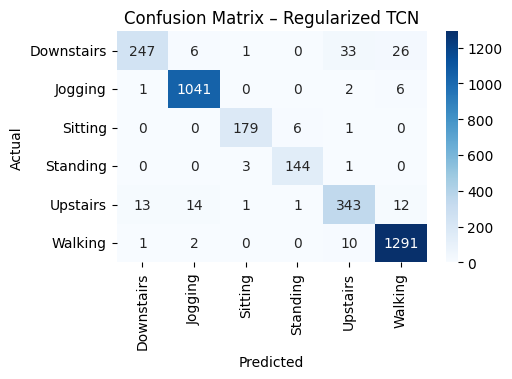

In [ ]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 1. FIX LABEL FORMAT (SAFETY)
if len(y_train.shape) == 2:
    y_train_fix = np.argmax(y_train, axis=1)
    y_test_fix  = np.argmax(y_test, axis=1)
else:
    y_train_fix = y_train
    y_test_fix  = y_test

# 2. REBUILD A SLIGHTLY WEAKER TCN
num_classes = len(np.unique(y_train_fix))

inputs = tf.keras.Input(shape=(X_train.shape[1], X_train.shape[2]))

# Add small noise
x = tf.keras.layers.GaussianNoise(0.02)(inputs)

x = tf.keras.layers.Conv1D(48, 5, padding='causal')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.45)(x)

x = tf.keras.layers.Conv1D(96, 5, padding='causal')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.55)(x)

x = tf.keras.layers.GlobalAveragePooling1D()(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# 3. COMPILE
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. TRAIN (EARLY STOP)
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train,
    y_train_fix,
    epochs=25,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# 5. EVALUATE
test_loss, test_accuracy = model.evaluate(X_test, y_test_fix, verbose=0)
print(f"\n Final Accuracy: {test_accuracy * 100:.2f}%\n")

# 6. REPORTS
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Classification Report:\n")
print(classification_report(y_test_fix, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test_fix, y_pred)

plt.figure(figsize=(5,3))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix – Regularized TCN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

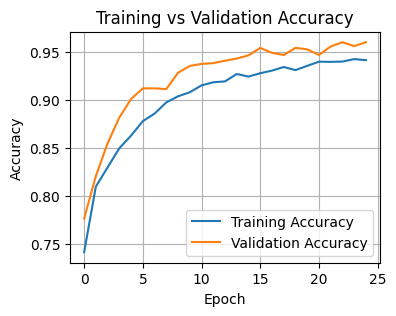

In [ ]:
plt.figure(figsize=(4,3))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

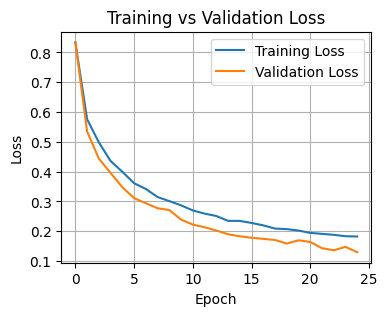

In [ ]:
plt.figure(figsize=(4,3))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

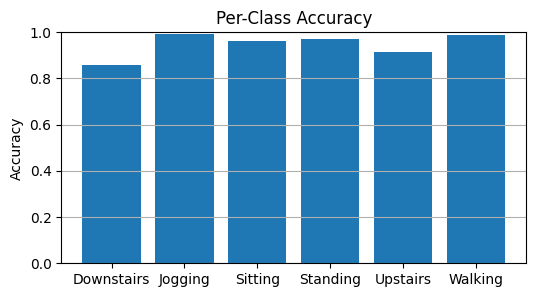

In [ ]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(6,3))
plt.bar(le.classes_, class_accuracy)
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.grid(axis='y')
plt.show()


In [ ]:
import tensorflow as tf

tiny_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 3)),   # window_size, channels

    tf.keras.layers.Conv1D(16, 3, padding='causal', activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv1D(32, 3, padding='causal', activation='relu'),

    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(6, activation='softmax')  # 6 activities
])

tiny_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tiny_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 128, 16)        │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 128, 32)        │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,926 (7.52 KB)

 Trainable params: 1,926 (7.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
tiny_model.fit(
    X_train,
    y_train_fix,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.3441 - loss: 1.6268 - val_accuracy: 0.6702 - val_loss: 1.0405
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6914 - loss: 0.9861 - val_accuracy: 0.7249 - val_loss: 0.8266
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7280 - loss: 0.8046 - val_accuracy: 0.7563 - val_loss: 0.6845
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7675 - loss: 0.6674 - val_accuracy: 0.7987 - val_loss: 0.5768
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8035 - loss: 0.5732 - val_accuracy: 0.8139 - val_loss: 0.5140
Epoch 6/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8252 - loss: 0.5100 - val_accuracy: 0.8187 - val_loss: 0.4839
Epoch 7/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8316 - loss: 0.4665 - val_accuracy: 0.8275 - val_loss: 0.4556
Epoch 8/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8332 - loss: 0.4674 - val_accuracy: 0

In [ ]:
def representative_dataset():
    for i in range(100):
        yield [X_train[i:i+1].astype(np.float32)]

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(8, 3, activation='relu', input_shape=(128,6)),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(16, 3, activation='relu'),
    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 126, 8)         │           152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 61, 16)         │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 926 (3.62 KB)

 Trainable params: 926 (3.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np

X_train = np.random.rand(1000,128,6)
y_train = tf.keras.utils.to_categorical(np.random.randint(0,6,1000),6)

model.fit(X_train, y_train, epochs=20)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.1426 - loss: 1.8205
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1797 - loss: 1.7900
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1773 - loss: 1.7859
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1989 - loss: 1.7854
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1997 - loss: 1.7843
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1988 - loss: 1.7884
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1903 - loss: 1.7836
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2118 - loss: 1.7865
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2021 - loss: 1.7866
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1822 - loss: 1.7904
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1829 - loss: 1.7811
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1783 - l

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# IMPORTANT: do NOT add optimizations
converter.optimizations = []

tflite_model = converter.convert()

with open("har_model.tflite","wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp_zgbba4h'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor_18')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  138483599231312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138483599235536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138483599235920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138483599236496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138483599234960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138483599235344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138483599234576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138483599234768: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
with open("har_model.tflite","rb") as f:
    model_bytes = f.read()

with open("har_tiny_model.h","w") as f:
    f.write("const unsigned char har_tiny_model_tflite[] = {")
    f.write(",".join(str(b) for b in model_bytes))
    f.write("};")

In [ ]:
from google.colab import files
files.download("har_tiny_model.h")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf

# Example input size (adjust to your dataset)
input_shape = (128,6)

model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=input_shape),

    tf.keras.layers.Conv1D(
        filters=8,
        kernel_size=3,
        activation='relu'
    ),

    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(
        filters=16,
        kernel_size=3,
        activation='relu'
    ),

    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 126, 8)         │           152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 61, 16)         │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654 (2.55 KB)

 Trainable params: 654 (2.55 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, epochs=20)

Epoch 1/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9316 - loss: 0.2066
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9345 - loss: 0.1988
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9363 - loss: 0.1897
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9394 - loss: 0.1850
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9436 - loss: 0.1775
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9419 - loss: 0.1765
Epoch 7/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9449 - loss: 0.1688
Epoch 8/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9433 - loss: 0.1703
Epoch 9/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9470 - loss: 0.1663
Epoch 10/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9497 - loss: 0.1595
Epoch 11/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9480 - loss: 0.1593
Epoch 12/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

In [ ]:
# Duplicate existing features to create 6 features per timestep
# This is done to match the input shape (None, 128, 6) expected by a later model.
X = np.concatenate([X, X], axis=-1)
print(f"X shape after duplicating features: {X.shape}")

X shape after duplicating features: (16922, 128, 6)


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Representative dataset
def representative_data():
    for i in range(100):
        yield [X_train[i:i+1].astype('float32')]

converter.representative_dataset = representative_data

tflite_model = converter.convert()

open("har_model.tflite","wb").write(tflite_model)

Saved artifact at '/tmp/tmp1xxwyfx9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor_18')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  139382796223696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139382796227536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139382796227920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139382796227152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139382796227344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139382796226768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139382796223312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139382796224272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139382796228496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139382796228688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139382796224656:

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


35104

In [ ]:
import numpy as np

with open("har_model.tflite", "rb") as f:
    model = f.read()

with open("har_tiny_model.h", "w") as f:
    f.write("const unsigned char har_tiny_model_tflite[] PROGMEM = {")
    f.write(",".join(str(b) for b in model))
    f.write("};")

In [ ]:
from google.colab import files
files.download("har_tiny_model.h")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>